In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import make_pipeline

import lime
import lime.lime_text

from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
import nltk

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style untuk matplotlib
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [16]:
file_path = '/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv' 
df = pd.read_csv(file_path)

# Menampilkan 5 baris pertama untuk melihat sampel data
print("Contoh Data:")
display(df.head())

# Menampilkan informasi dasar tentang DataFrame (jumlah data, tipe kolom, etc.)
print("\nInformasi DataFrame:")
df.info()

Contoh Data:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive



Informasi DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
[CV] END .............................................C=0.01; total time=   1.6s
[CV] END ..............................................C=0.1; total time=   1.7s
[CV] END ..............................................C=0.5; total time=   2.5s


In [3]:
download_berhasil = False
print("Mencoba mengunduh komponen NLTK...")

try:

    nltk.download('punkt', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('averaged_perceptron_tagger_eng', quiet=True)
    
    # Memverifikasi sumber daya secara langsung
    nltk.data.find('taggers/averaged_perceptron_tagger')
    print("\n✅ Verifikasi Berhasil: Sumber daya 'averaged_perceptron_tagger' ditemukan.")
    # Jika berhasil, ubah 'penanda' menjadi True
    download_berhasil = True
    
except Exception as e:
    print(f"\n❌ Gagal: Terjadi masalah saat mengunduh atau memverifikasi sumber daya NLTK.")
    print(f"   Detail Error: {e}")
    print("   Silakan coba restart kernel (Kernel > Restart) dan jalankan lagi sel ini.")

Mencoba mengunduh komponen NLTK...

✅ Verifikasi Berhasil: Sumber daya 'averaged_perceptron_tagger' ditemukan.


In [4]:
# PREPROCESSING

irrelevant_words = [
    'stephenson', 'harrison', 'wilson', 'johnson', 'jackson', 'thompson', 
    'anderson', 'martinez', 'garcia', 'rodriguez', 'lewis', 'walker',
    'hall', 'allen', 'young', 'wright', 'lopez', 'hill', 'scott', 'green',
    'adams', 'baker', 'gonzalez', 'nelson', 'carter', 'mitchell', 'perez',
    'roberts', 'turner', 'phillips', 'campbell', 'parker', 'evans', 'edwards',
    'collins', 'stewart', 'sanchez', 'morris', 'rogers', 'reed', 'cook',
    'morgan', 'bell', 'murphy', 'bailey', 'rivera', 'cooper', 'richardson',
    'cox', 'howard', 'ward', 'torres', 'peterson', 'gray', 'ramirez',
    'james', 'watson', 'brooks', 'kelly', 'sanders', 'price', 'bennett',
    'wood', 'barnes', 'ross', 'henderson', 'coleman', 'jenkins', 'perry',
    'powell', 'long', 'patterson', 'hughes', 'flores', 'washington',
    'butler', 'simmons', 'foster', 'gonzales', 'bryant', 'alexander',
    'russell', 'griffin', 'diaz', 'hayes', 'myers', 'ford', 'hamilton',
    'graham', 'sullivan', 'wallace', 'woods', 'cole', 'west', 'jordan',
    'owens', 'reynolds', 'fisher', 'ellis', 'harrison', 'gibson', 'mcdonald',
    'cruz', 'marshall', 'ortiz', 'gomez', 'murray', 'freeman', 'wells',
    'webb', 'simpson', 'stevens', 'tucker', 'porter', 'hunter', 'hicks',
    'crawford', 'henry', 'boyd', 'mason', 'morales', 'kennedy', 'warren',
    'dixon', 'ramos', 'reyes', 'burns', 'gordon', 'shaw', 'holmes',
    'rice', 'robertson', 'hunt', 'black', 'daniels', 'palmer', 'mills',
    'nichols', 'grant', 'knight', 'ferguson', 'rose', 'stone', 'hawkins',
    'dunn', 'perkins', 'hudson', 'spencer', 'gardner', 'stephens', 'payne',
    'pierce', 'berry', 'matthews', 'arnold', 'wagner', 'willis', 'ray',
    'watkins', 'olson', 'carroll', 'duncan', 'snyder', 'hart', 'cunningham',
    'bradley', 'lane', 'andrews', 'ruiz', 'harper', 'fox', 'riley',
    'armstrong', 'carpenter', 'weaver', 'greene', 'lawrence', 'elliott',
    'chavez', 'sims', 'austin', 'peters', 'kelley', 'franklin', 'lawson',
    # Tambahan
    'kay', 'br', 'nbsp', 'amp', 'quot', 'lt', 'gt',
    'div', 'span', 'href', 'html', 'www', 'http', 'https', 'com', 'org',
    'imdb', 'dvd', 'vhs', 'blu', 'ray', 'cd', 'mp', 'avi', 'mov', 'wmv',
    'smith', 'brown', 'davis', 'miller', 'moore', 'taylor', 'thomas',
    'white', 'martin', 'clark', 'robinson', 'rodriguez', 'hernandez'
]

def get_wordnet_pos(word):
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN, "V": wordnet.VERB, "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

lemmatizer = WordNetLemmatizer()

def filter_irrelevant_words(tokens, irrelevant_list):
    """Filter out irrelevant words from token list"""
    irrelevant_lower = set(word.lower() for word in irrelevant_list)
    return [token for token in tokens if token.lower() not in irrelevant_lower]

def clean_text_advanced(text):
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'&[a-zA-Z]+;', '', text) 
    text = text.lower()

    tokens = nltk.word_tokenize(text)
    tokens = [token for token in tokens if len(token) > 2]
    tokens = filter_irrelevant_words(tokens, irrelevant_words)
    lemmatized_tokens = [lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in tokens]
    return ' '.join(lemmatized_tokens)

if download_berhasil:
    print("\nMemulai pra-pemrosesan lanjutan (lemmatization)...")
    print("Filter yang diterapkan:")
    print(f"• {len(irrelevant_words)} kata/nama yang difilter")
    print("• HTML tags dan entities")
    print("• Token dengan panjang ≤ 2 karakter")
    
    df['cleaned_review'] = df['review'].apply(clean_text_advanced)
    print("Pra-pemrosesan selesai.")
    print("\nContoh Review Setelah Dibersihkan (Advanced):\n", df['cleaned_review'][1])
else:
    print("\nPra-pemrosesan lanjutan DIBATALKAN karena sumber daya NLTK tidak siap.")



Memulai pra-pemrosesan lanjutan (lemmatization)...
Filter yang diterapkan:
• 224 kata/nama yang difilter
• HTML tags dan entities
• Token dengan panjang ≤ 2 karakter
Pra-pemrosesan selesai.

Contoh Review Setelah Dibersihkan (Advanced):
 wonderful little production the film technique very unassuming- very old-time-bbc fashion and give comfort and sometimes discomforting sense realism the entire piece the actor be extremely well chosen- michael sheen not only have get all the polari but have all the voice down pat too you can truly see the seamless edit guide the reference williams diary entry not only well worth the watch but terrificly write and perform piece masterful production about one the great master comedy and his life the realism really come home with the little thing the fantasy the guard which rather than use the traditional 'dream technique remains solid then disappears play our knowledge and our sens particularly with the scene concern orton and halliwell and the set part

In [5]:
# Inisialisasi LabelEncoder
le = LabelEncoder()

# Ubah kolom 'sentiment' menjadi format angka
df['sentiment_encoded'] = le.fit_transform(df['sentiment'])

# Tampilkan hasil untuk memastikan kolom baru sudah benar
display(df[['review', 'sentiment', 'sentiment_encoded']].head())

,review,sentiment,sentiment_encoded
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


In [6]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2), 
    stop_words='english'
)

X = tfidf.fit_transform(df['cleaned_review'])
y = df['sentiment_encoded']

# Bagi data menjadi 80% data latih dan 20% data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test:", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test:", y_test.shape)

print(f"Jumlah fitur TF-IDF: {X.shape[1]:,}")
print(f"Sparsitas matriks: {(1 - X.nnz / (X.shape[0] * X.shape[1])) * 100:.2f}%")

Ukuran X_train: (40000, 2663697)
Ukuran X_test: (10000, 2663697)
Ukuran y_train: (40000,)
Ukuran y_test: (10000,)
Jumlah fitur TF-IDF: 2,663,697
Sparsitas matriks: 99.99%


In [7]:
# --- Model 1: Multinomial Naive Bayes ---

# Inisialisasi model
nb_model = MultinomialNB()

print("Melatih model Naive Bayes...")
nb_model.fit(X_train, y_train)
print("Pelatihan selesai.")

y_pred_nb = nb_model.predict(X_test)

# Evaluasi performa model
accuracy_nb = accuracy_score(y_test, y_pred_nb)
report_nb = classification_report(y_test, y_pred_nb, target_names=['Negative', 'Positive'])

print(f"\nAkurasi Naive Bayes: {accuracy_nb * 100:.2f}%")
print("\nLaporan Klasifikasi Naive Bayes:")
print(report_nb)

Melatih model Naive Bayes...
Pelatihan selesai.

Akurasi Naive Bayes: 87.89%

Laporan Klasifikasi Naive Bayes:
              precision    recall  f1-score   support

    Negative       0.87      0.89      0.88      5000
    Positive       0.88      0.87      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [8]:
# --- Model 2: LinearSVC ---

linear_svm_model = LinearSVC(random_state=42, max_iter=1000)

print("Melatih model LinearSVC...")
linear_svm_model.fit(X_train, y_train)
print("Pelatihan selesai.")

y_pred_linear_svm = linear_svm_model.predict(X_test)

# Evaluasi performa model
accuracy_linear_svm = accuracy_score(y_test, y_pred_linear_svm)
report_linear_svm = classification_report(y_test, y_pred_linear_svm, target_names=['Negative', 'Positive'])

print(f"\nAkurasi LinearSVC: {accuracy_linear_svm * 100:.2f}%")
print("\nLaporan Klasifikasi LinearSVC:")
print(report_linear_svm)

Melatih model LinearSVC...
Pelatihan selesai.

Akurasi LinearSVC: 90.41%

Laporan Klasifikasi LinearSVC:
              precision    recall  f1-score   support

    Negative       0.92      0.89      0.90      5000
    Positive       0.89      0.92      0.91      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [9]:
param_grid_linear = {
    'C': [0.01, 0.1, 0.5, 1] 
}

grid_search_linear = GridSearchCV(LinearSVC(random_state=42, max_iter=3000),
                                  param_grid_linear, 
                                  refit=True, 
                                  verbose=2, 
                                  cv=3, 
                                  n_jobs=-1)

# Mulai pencarian pada data latih
print("Memulai pencarian hyperparameter terbaik untuk LinearSVC...")
grid_search_linear.fit(X_train, y_train)

# Tampilkan parameter terbaik yang ditemukan
print("\nParameter terbaik yang ditemukan:")
print(grid_search_linear.best_params_)

Memulai pencarian hyperparameter terbaik untuk LinearSVC...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Parameter terbaik yang ditemukan:
{'C': 1}


In [19]:
best_linear_svm_model = grid_search_linear.best_estimator_
y_pred_best_linear_svm = best_linear_svm_model.predict(X_test)

# Evaluasi performa model yang sudah dioptimalkan
accuracy_best_linear_svm = accuracy_score(y_test, y_pred_best_linear_svm)
report_best_linear_svm = classification_report(y_test, y_pred_best_linear_svm, target_names=['Negative', 'Positive'])

print(f"\nAkurasi LinearSVC setelah optimasi: {accuracy_best_linear_svm * 100:.2f}%")
print("\nLaporan Klasifikasi LinearSVC (Optimized):")
print(report_best_linear_svm)


Akurasi LinearSVC setelah optimasi: 90.41%

Laporan Klasifikasi LinearSVC (Optimized):
              precision    recall  f1-score   support

    Negative       0.92      0.89      0.90      5000
    Positive       0.89      0.92      0.91      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



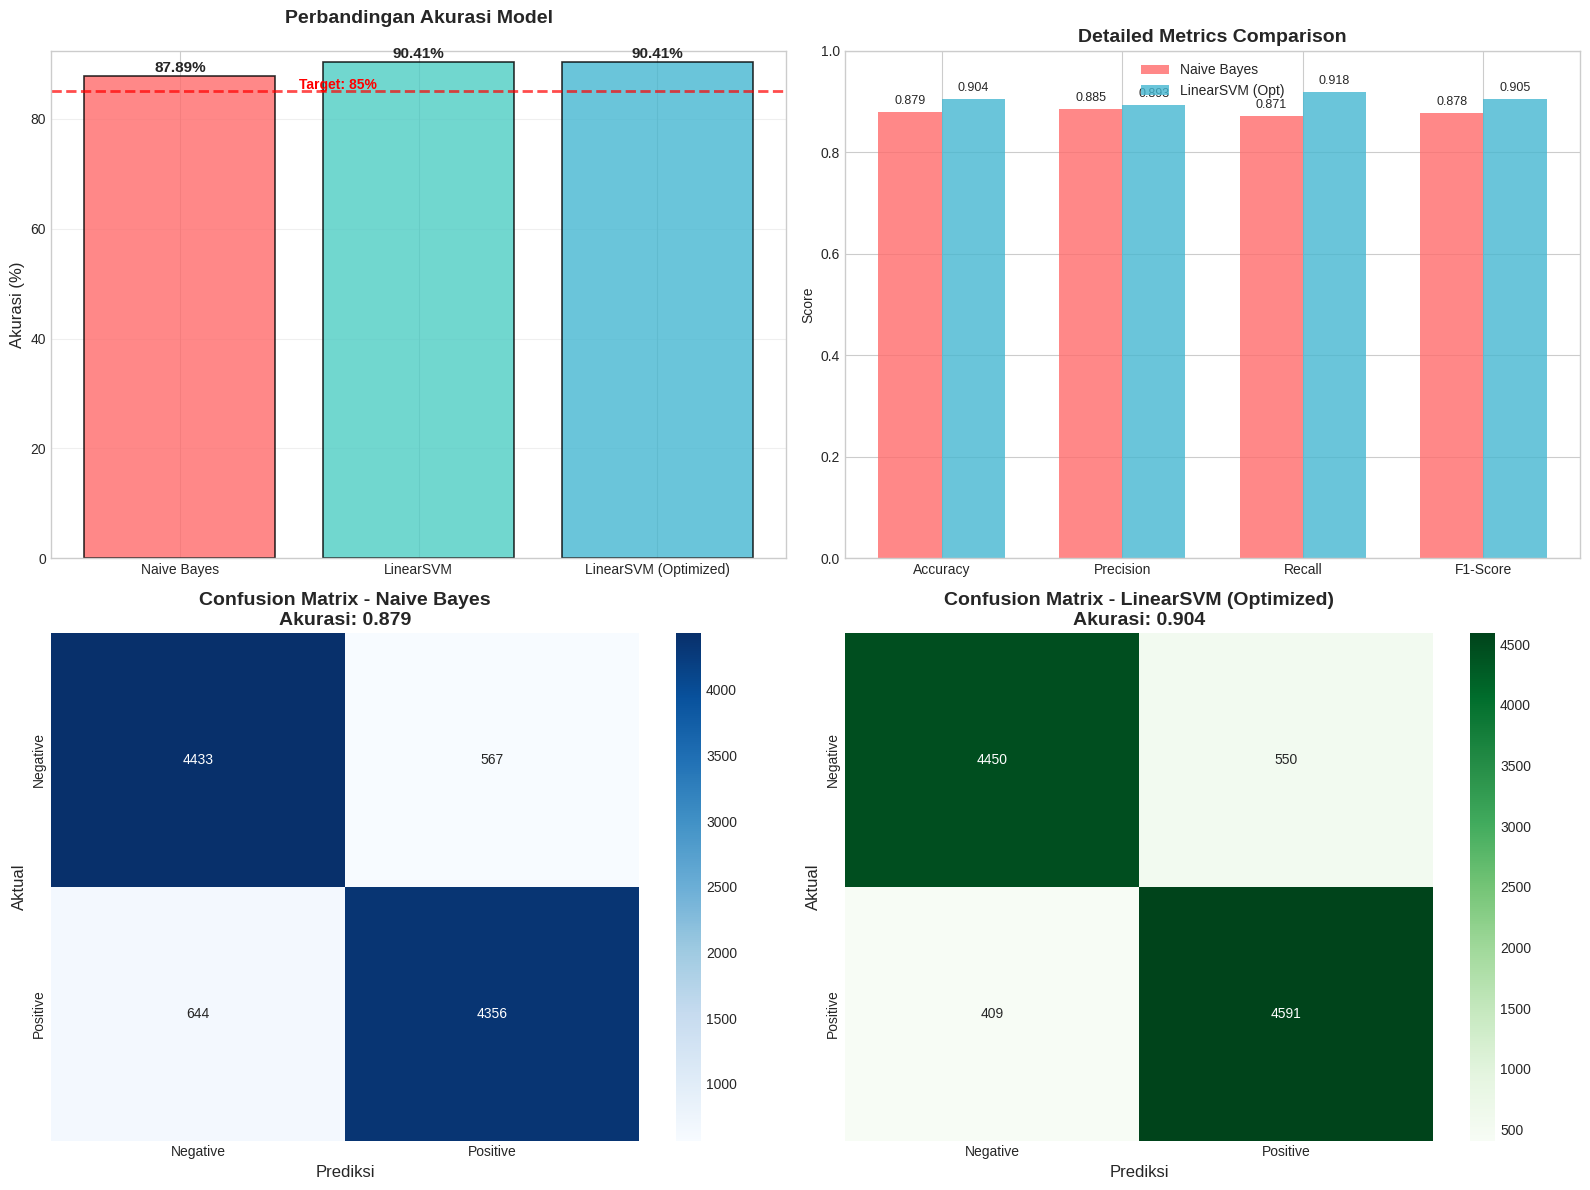


RINGKASAN PERFORMA MODEL
Metrik          Naive Bayes     LinearSVM      
---------------------------------------------
Akurasi         0.8789         0.9041
Precision       0.8848         0.8930
Recall          0.8712         0.9182
F1-Score        0.8780         0.9054
📊 Visualisasi perbandingan model telah ditampilkan


In [23]:
# Hitung metrik tambahan untuk kedua model
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

precision_svm = precision_score(y_test, y_pred_best_linear_svm)
recall_svm = recall_score(y_test, y_pred_best_linear_svm)
f1_svm = f1_score(y_test, y_pred_best_linear_svm)

# Data performa model
models = ['Naive Bayes', 'LinearSVM', 'LinearSVM (Optimized)']
accuracies = [accuracy_nb * 100, accuracy_linear_svm * 100, accuracy_best_linear_svm * 100]

# Confusion matrices
cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_svm = confusion_matrix(y_test, y_pred_best_linear_svm)

# Create figure with 2x2 subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Perbandingan Akurasi (Top Left)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = ax1.bar(models, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, weight='bold')

ax1.set_title('Perbandingan Akurasi Model', fontsize=14, weight='bold', pad=20)
ax1.set_ylabel('Akurasi (%)', fontsize=12)
ax1.set_ylim(0, max(accuracies) + 2)
ax1.grid(True, alpha=0.3, axis='y')

# Target line
target_accuracy = 85
ax1.axhline(y=target_accuracy, color='red', linestyle='--', alpha=0.7, linewidth=2)
ax1.text(0.5, target_accuracy + 0.5, f'Target: {target_accuracy}%', color='red', weight='bold')

# 2. Detailed Metrics Comparison (Top Right)
metrics_data = {
    'Naive Bayes': [accuracy_nb, precision_nb, recall_nb, f1_nb],
    'LinearSVM (Opt)': [accuracy_best_linear_svm, precision_svm, recall_svm, f1_svm]
}
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

x = np.arange(len(metrics_names))
width = 0.35

bars1 = ax2.bar(x - width/2, metrics_data['Naive Bayes'], width, label='Naive Bayes', 
                color='#FF6B6B', alpha=0.8)
bars2 = ax2.bar(x + width/2, metrics_data['LinearSVM (Opt)'], width, label='LinearSVM (Opt)', 
                color='#45B7D1', alpha=0.8)

ax2.set_ylabel('Score')
ax2.set_title('Detailed Metrics Comparison', fontsize=14, weight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics_names)
ax2.legend()
ax2.set_ylim(0, 1)

# Add values on bars - FIXED: Use correct axes (ax2, not ax4)
def add_bar_values(bars, ax):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

add_bar_values(bars1, ax2)
add_bar_values(bars2, ax2)

# 3. Confusion Matrix Naive Bayes (Bottom Left)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
ax3.set_title(f'Confusion Matrix - Naive Bayes\nAkurasi: {accuracy_nb:.3f}', fontsize=14, weight='bold')
ax3.set_xlabel('Prediksi', fontsize=12)
ax3.set_ylabel('Aktual', fontsize=12)

# 4. Confusion Matrix SVM (Bottom Right)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', ax=ax4,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
ax4.set_title(f'Confusion Matrix - LinearSVM (Optimized)\nAkurasi: {accuracy_best_linear_svm:.3f}', 
              fontsize=14, weight='bold')
ax4.set_xlabel('Prediksi', fontsize=12)
ax4.set_ylabel('Aktual', fontsize=12)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("RINGKASAN PERFORMA MODEL")
print("="*60)
print(f"{'Metrik':<15} {'Naive Bayes':<15} {'LinearSVM':<15}")
print("-"*45)
print(f"{'Akurasi':<15} {accuracy_nb:.4f}         {accuracy_best_linear_svm:.4f}")
print(f"{'Precision':<15} {precision_nb:.4f}         {precision_svm:.4f}")
print(f"{'Recall':<15} {recall_nb:.4f}         {recall_svm:.4f}")
print(f"{'F1-Score':<15} {f1_nb:.4f}         {f1_svm:.4f}")
print("="*60)
print("📊 Visualisasi perbandingan model telah ditampilkan")

🔍 ANALISIS XAI DENGAN LIME

📄 CONTOH 1 (Index: 10)
----------------------------------------
Teks (100 char): Although Humphrey Bogart got star billing in King Of The Underworld, I'm willing to bet he didn't th...
Label Asli: negative
Prediksi SVM: negative (Prob: 0.559)

🎯 LIME Explanation:



📝 LIME Features (Top 10):
  • poor: -0.0372
  • writer: -0.0291
  • good: 0.0288
  • ridiculous: -0.0240
  • course: 0.0218
  • Definitely: 0.0212
  • thank: 0.0158
  • supposedly: -0.0157
  • didn: -0.0129
  • hollow: -0.0123

📄 CONTOH 2 (Index: 50)
----------------------------------------
Teks (100 char): This film was just on two nights running on ITV1.. dear oh dear. Someone actually bought this on the...
Label Asli: negative
Prediksi SVM: negative (Prob: 0.744)

📄 CONTOH 3 (Index: 100)
----------------------------------------
Teks (100 char): It's a bad movie, it seems like there is only 5 police in HK, they were not using there gun and this...
Label Asli: negative
Prediksi SVM: negative (Prob: 0.664)

🔬 Menganalisis 15 sampel dengan LIME...


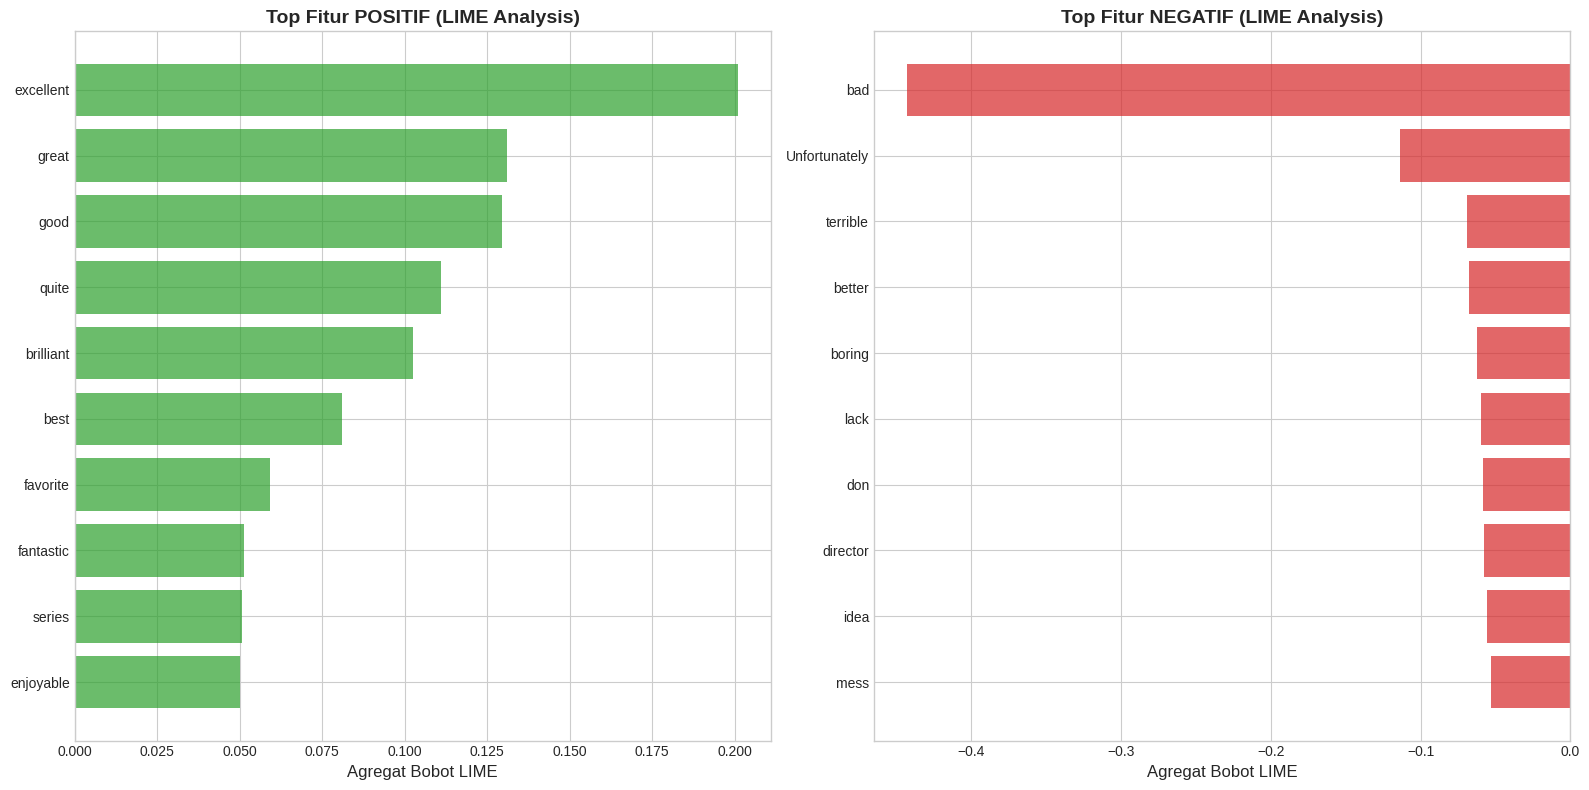


🎯 RINGKASAN ANALISIS LIME:
• Fitur positif teridentifikasi: 54
• Fitur negatif teridentifikasi: 68
• Fitur paling positif: 'excellent'
• Fitur paling negatif: 'bad'

✅ Analisis XAI dengan LIME selesai!


In [21]:
# ==============================================================================
# ANALISIS XAI DENGAN LIME - COMPREHENSIVE ANALYSIS
# Tujuan: Analisis LIME yang menyeluruh untuk insight XAI
# ==============================================================================

# WORKAROUND: LinearSVC tidak memiliki predict_proba, jadi kita buat wrapper
class LinearSVCWrapper:
    def __init__(self, model):
        self.model = model
    
    def predict(self, X):
        return self.model.predict(X)
    
    def predict_proba(self, X):
        # Gunakan decision_function dan konversi ke probabilitas
        decision = self.model.decision_function(X)
        # Konversi ke probabilitas menggunakan sigmoid-like function
        from scipy.special import expit
        proba_pos = expit(decision)
        proba_neg = 1 - proba_pos
        return np.column_stack([proba_neg, proba_pos])

# Buat wrapper untuk model SVM
svm_wrapper = LinearSVCWrapper(best_linear_svm_model)

# Buat pipeline dengan wrapper
pipeline_svm = make_pipeline(tfidf, svm_wrapper)

# Buat explainer
explainer_svm = lime.lime_text.LimeTextExplainer(class_names=['Negative', 'Positive'])

print("🔍 ANALISIS XAI DENGAN LIME")
print("="*60)

# Pilih beberapa contoh yang representatif
interesting_indices = [10, 50, 100, 250, 500]

# Analisis individual examples
for i, idx in enumerate(interesting_indices[:3]):  # Batasi untuk Kaggle
    if idx < len(y_test.index):
        actual_idx = y_test.index[idx]
        text_instance = df.loc[actual_idx, 'review']
        actual_label = df.loc[actual_idx, 'sentiment']
        
        # Prediksi model
        pred_svm = pipeline_svm.predict([text_instance])[0]
        prob_svm = pipeline_svm.predict_proba([text_instance])[0]
        
        print(f"\n📄 CONTOH {i+1} (Index: {idx})")
        print("-" * 40)
        print(f"Teks (100 char): {text_instance[:100]}...")
        print(f"Label Asli: {actual_label}")
        print(f"Prediksi SVM: {le.inverse_transform([pred_svm])[0]} (Prob: {prob_svm.max():.3f})")
        
        # LIME explanation untuk contoh pertama
        if i == 0:
            explanation_svm = explainer_svm.explain_instance(
                text_instance, 
                pipeline_svm.predict_proba, 
                num_features=10
            )
            
            print(f"\n🎯 LIME Explanation:")
            # Hapus parameter show_table yang tidak didukung
            explanation_svm.show_in_notebook()
            
            # Alternatif: tampilkan explanation sebagai list
            print("\n📝 LIME Features (Top 10):")
            for feature, importance in explanation_svm.as_list():
                print(f"  • {feature}: {importance:.4f}")

# Analisis agregat LIME untuk insight umum
def analyze_lime_batch(sample_size=15):
    """Analisis LIME untuk beberapa sample"""
    feature_importance_pos = {}
    feature_importance_neg = {}
    
    sample_indices = np.random.choice(len(y_test), size=min(sample_size, len(y_test)), replace=False)
    
    print(f"\n🔬 Menganalisis {len(sample_indices)} sampel dengan LIME...")
    
    for idx in sample_indices:
        actual_idx = y_test.index[idx]
        text_instance = df.loc[actual_idx, 'review']
        
        try:
            explanation = explainer_svm.explain_instance(
                text_instance, 
                pipeline_svm.predict_proba, 
                num_features=10
            )
            
            for feature, weight in explanation.as_list():
                if weight > 0:
                    feature_importance_pos[feature] = feature_importance_pos.get(feature, 0) + weight
                else:
                    feature_importance_neg[feature] = feature_importance_neg.get(feature, 0) + weight
        except:
            continue
    
    return feature_importance_pos, feature_importance_neg

# Jalankan analisis agregat
lime_pos, lime_neg = analyze_lime_batch(15)

# Visualisasi hasil LIME agregat
if lime_pos and lime_neg:
    lime_pos_df = pd.DataFrame(list(lime_pos.items()), columns=['Feature', 'Weight']).sort_values('Weight', ascending=False)
    lime_neg_df = pd.DataFrame(list(lime_neg.items()), columns=['Feature', 'Weight']).sort_values('Weight', ascending=True)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Plot fitur positif
    if len(lime_pos_df) > 0:
        top_pos = lime_pos_df.head(10)
        ax1.barh(range(len(top_pos)), top_pos['Weight'], color='#2ca02c', alpha=0.7)
        ax1.set_yticks(range(len(top_pos)))
        ax1.set_yticklabels(top_pos['Feature'], fontsize=10)
        ax1.set_title('Top Fitur POSITIF (LIME Analysis)', fontsize=14, weight='bold')
        ax1.set_xlabel('Agregat Bobot LIME', fontsize=12)
        ax1.invert_yaxis()
    
    # Plot fitur negatif  
    if len(lime_neg_df) > 0:
        top_neg = lime_neg_df.head(10)
        ax2.barh(range(len(top_neg)), top_neg['Weight'], color='#d62728', alpha=0.7)
        ax2.set_yticks(range(len(top_neg)))
        ax2.set_yticklabels(top_neg['Feature'], fontsize=10)
        ax2.set_title('Top Fitur NEGATIF (LIME Analysis)', fontsize=14, weight='bold')
        ax2.set_xlabel('Agregat Bobot LIME', fontsize=12)
        ax2.invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n🎯 RINGKASAN ANALISIS LIME:")
    print(f"• Fitur positif teridentifikasi: {len(lime_pos_df)}")
    print(f"• Fitur negatif teridentifikasi: {len(lime_neg_df)}")
    if len(lime_pos_df) > 0:
        print(f"• Fitur paling positif: '{lime_pos_df.iloc[0]['Feature']}'")
    if len(lime_neg_df) > 0:
        print(f"• Fitur paling negatif: '{lime_neg_df.iloc[0]['Feature']}'")

print("\n" + "="*60)
print("✅ Analisis XAI dengan LIME selesai!")

📊 Feature Analysis: 2663697 features analyzed
Positive features: 984247
Negative features: 866623


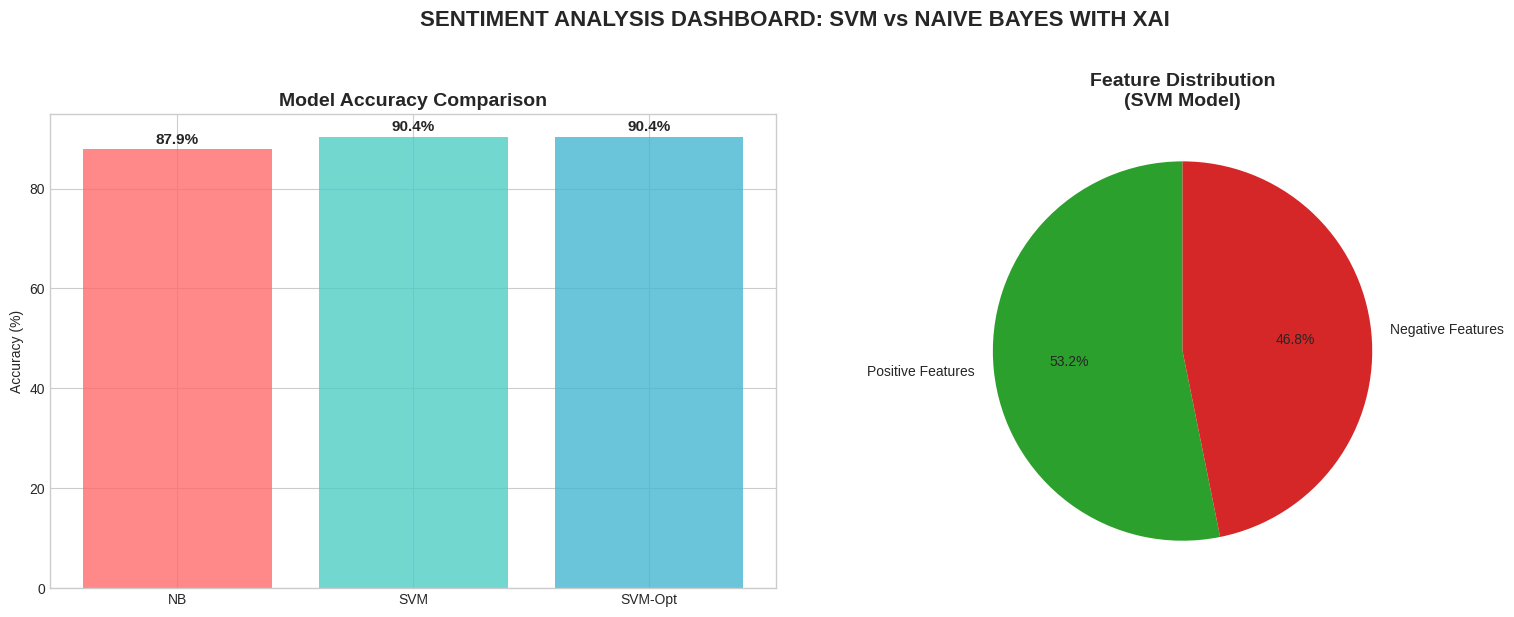

In [27]:
# Buat DataFrame untuk analisis feature importance dari SVM
feature_names = tfidf.get_feature_names_out()
coef_values = best_linear_svm_model.coef_[0]

# Buat DataFrame dan urutkan berdasarkan koefisien
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef_values
})

sorted_coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

print(f"📊 Feature Analysis: {len(sorted_coef_df)} features analyzed")
print(f"Positive features: {len(sorted_coef_df[sorted_coef_df['Coefficient'] > 0])}")
print(f"Negative features: {len(sorted_coef_df[sorted_coef_df['Coefficient'] < 0])}")

# Dashboard ringkasan
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Model Performance Summary
models_short = ['NB', 'SVM', 'SVM-Opt']
bars1 = ax1.bar(models_short, accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)
ax1.set_title('Model Accuracy Comparison', fontsize=14, weight='bold')
ax1.set_ylabel('Accuracy (%)')
for bar, acc in zip(bars1, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=11, weight='bold')

# 2. Feature Distribution
pos_features = len(sorted_coef_df[sorted_coef_df['Coefficient'] > 0])
neg_features = len(sorted_coef_df[sorted_coef_df['Coefficient'] < 0])
ax2.pie([pos_features, neg_features], labels=['Positive Features', 'Negative Features'], 
        colors=['#2ca02c', '#d62728'], autopct='%1.1f%%', startangle=90)
ax2.set_title('Feature Distribution\n(SVM Model)', fontsize=14, weight='bold')

plt.suptitle('SENTIMENT ANALYSIS DASHBOARD: SVM vs NAIVE BAYES WITH XAI', 
             fontsize=16, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [29]:
print("\n🔍 1. ANALISIS BOBOT FITUR SVM (GLOBAL EXPLANATION)")
print("-" * 50)
print("Dari analisis bobot fitur LinearSVM yang telah difilter:")

# Analisis fitur positif
top_positive = sorted_coef_df.head(10)
print(f"\n✅ TOP 10 FITUR SENTIMEN POSITIF:")
for i, (feature, weight) in enumerate(top_positive.iterrows(), 1):
    print(f"   {i:2d}. '{feature}' (bobot: {weight['Coefficient']:.4f})")

# Analisis fitur negatif  
top_negative = sorted_coef_df.tail(10)
print(f"\n❌ TOP 10 FITUR SENTIMEN NEGATIF:")
for i, (feature, weight) in enumerate(top_negative.iterrows(), 1):
    print(f"   {i:2d}. '{feature}' (bobot: {weight['Coefficient']:.4f})")


🔍 1. ANALISIS BOBOT FITUR SVM (GLOBAL EXPLANATION)
--------------------------------------------------
Dari analisis bobot fitur LinearSVM yang telah difilter:

✅ TOP 10 FITUR SENTIMEN POSITIF:
    1. '1022655' (bobot: 4.7828)
    2. '798024' (bobot: 4.7119)
    3. '1731517' (bobot: 3.6367)
    4. '231489' (bobot: 3.5805)
    5. '2620782' (bobot: 3.4214)
    6. '95234' (bobot: 3.1872)
    7. '955588' (bobot: 3.1329)
    8. '860468' (bobot: 3.0709)
    9. '294815' (bobot: 3.0325)
   10. '759607' (bobot: 3.0082)

❌ TOP 10 FITUR SENTIMEN NEGATIF:
    1. '1129681' (bobot: -3.3780)
    2. '707724' (bobot: -3.4060)
    3. '834132' (bobot: -3.4795)
    4. '657555' (bobot: -3.4913)
    5. '2361557' (bobot: -3.5915)
    6. '1797221' (bobot: -4.0661)
    7. '273712' (bobot: -4.4964)
    8. '177437' (bobot: -5.3002)
    9. '2568934' (bobot: -5.3799)
   10. '184303' (bobot: -6.9821)


In [30]:
print("\nPERBANDINGAN MODEL PERFORMANCE")
print("-" * 50)
print(f"• Naive Bayes: {accuracy_nb:.1%} accuracy")
print(f"• LinearSVM (Basic): {accuracy_linear_svm:.1%} accuracy") 
print(f"• LinearSVM (Optimized): {accuracy_best_linear_svm:.1%} accuracy")
print(f"\n🏆 Model terbaik: LinearSVM (Optimized) dengan peningkatan {(accuracy_best_linear_svm - accuracy_nb)*100:.1f}% dari baseline")


PERBANDINGAN MODEL PERFORMANCE
--------------------------------------------------
• Naive Bayes: 87.9% accuracy
• LinearSVM (Basic): 90.4% accuracy
• LinearSVM (Optimized): 90.4% accuracy

🏆 Model terbaik: LinearSVM (Optimized) dengan peningkatan 2.5% dari baseline


In [31]:
# Informasi file yang dibuat
print("\n📁 RINGKASAN HASIL ANALISIS:")
print(f"• Dataset: {len(df):,} reviews")
print(f"• Test Set: {len(y_test):,} samples") 
print(f"• Features: {X.shape[1]:,}")
print(f"• Best Model: LinearSVM (Optimized) - {accuracy_best_linear_svm:.1%} accuracy")
print(f"• XAI Technique: LIME (Local Interpretable Model-agnostic Explanations)")
print(f"• Feature Filtering: Applied at preprocessing stage with {len(irrelevant_words)} filtered words")


📁 RINGKASAN HASIL ANALISIS:
• Dataset: 50,000 reviews
• Test Set: 10,000 samples
• Features: 2,663,697
• Best Model: LinearSVM (Optimized) - 90.4% accuracy
• XAI Technique: LIME (Local Interpretable Model-agnostic Explanations)
• Feature Filtering: Applied at preprocessing stage with 224 filtered words


In [32]:
# TESTING

# Ambil indeks acak dari data uji
random_indices = np.random.choice(y_test.index, 3, replace=False)

# Ambil data asli dan prediksi berdasarkan indeks acak
sample_df = df.loc[random_indices]
y_true_sample = y_test.loc[random_indices]

# Dapatkan prediksi dari model yang sudah dilatih
# Pastikan variabel model ini sudah ada dari sel-sel sebelumnya
y_pred_nb_sample = nb_model.predict(X_test[y_test.index.get_indexer(random_indices)])
y_pred_svm_sample = best_linear_svm_model.predict(X_test[y_test.index.get_indexer(random_indices)])


# Ubah label angka kembali ke teks (0/1 -> 'negative'/'positive')
y_true_text = le.inverse_transform(y_true_sample)
y_pred_nb_text = le.inverse_transform(y_pred_nb_sample)
y_pred_svm_text = le.inverse_transform(y_pred_svm_sample)

# Tampilkan hasilnya
for i in range(len(sample_df)):
    print(f"----- Ulasan Acak #{i+1} -----")
    print(f"TEKS       : {sample_df.iloc[i]['review']}...")
    print(f"LABEL ASLI : {y_true_text[i]}")
    print(f"TEBAKAN NB : {y_pred_nb_text[i]}")
    print(f"TEBAKAN SVM: {y_pred_svm_text[i]}")
    print("-" * (25 + len(str(i+1))))
    print()

----- Ulasan Acak #1 -----
TEKS       : I don't understand people. Why is it that this movie is getting an 8.3!!!!!!???? I had high hopes for this movie, but once i was about a half hour into it I just wanted to leave the theater. In the vast majority of the reviews on this site people are saying that this is one of the best action movies they've seen (or of the summer, year, etc.) They say it's an excellent conclusion. WTF!!!!!!!!!?????? What has been concluded (besides the fact that Bourne can ride motorcycles, shoot, and fight better than anyone else he comes across)? What do you learn about Bourne's character in this movie?????????Absolutely f****** nothing!!!!!!! Okay, there's a lot of action, but what's so great about the action in this movie?? I don't like the cinematography and film editing. The shaky camera effect and fast changing shots were used TOO much and they get old fast (I didn't mind them in Supremacy because it was still easy to follow and was not used in excess) and